In [2]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import warnings
from datetime import datetime
import re
from treetime import TreeTime, TreeTimeError, utils
from dendropy import Tree
from Bio import SeqIO
import random
import math
import scipy.stats as stats

In [3]:
clades = ['na_avian', 'eurasian_avian', 'swine']

In [4]:
host_trees = {}

for clade in clades:
    
    path = f'hosts/{clade}/summary_baltic.nwk'
    mytree= bt.loadNewick(path, absoluteTime= False)

    
    host_trees[clade] = mytree

In [ ]:
json_path = "clock_rate/host_clock_rates.json"

with open(json_path) as f:
    host_stats = json.load(f)

In [ ]:
print(host_stats)

{'na_avian': {'clock_rate': 0.0014165118387662263, 'root_yr': 1932.5570895100057}, 'na_avian_subsetted': {'clock_rate': 0.0014647114639278263, 'root_yr': 1934.076328797454}, 'eurasian_avian': {'clock_rate': 0.0010913196445706257, 'root_yr': 1933.7710383824265}, 'swine': {'clock_rate': 0.004237804631416232, 'root_yr': 1969.0027397260274}, 'canine': {'clock_rate': 0.002252852088837512, 'root_yr': 2004.26089655557}, 'human': {'clock_rate': 0.004164468492498282, 'root_yr': 1967.5455355529202}, 'h3nx': {'clock_rate': 0.00220094613698407, 'root_yr': 1942.8374272293652}, 'equine': {'clock_rate': 0.0018970760397403674, 'root_yr': 1954.4947655075264}}


In [ ]:
current_year = 2025
fit_times = [0.5, 2, 6, 10]

results = {clade: {} for clade in clades}

for clade in clades:
    
    clock_rate = host_stats[clade]["clock_rate"]
    
    mytree = host_trees[clade] 
        
    mytree.traverse_tree()
    mytree.sortBranches()

    leaf_heights = {leaf.name: (leaf.height, leaf.name.split("|")[1]) for leaf in mytree.getExternal()}

    for fit_time in fit_times:

        node_count = node_rea_count = leaf_count = leaf_rea_count = 0
        rea_fit = clonal_fit = rea_unfit = clonal_unfit = 0

        for k in mytree.Objects:
            if k.is_leaf():
                leaf_count += 1
                if k.traits.get('is_reassorted'):
                    leaf_rea_count += 1
            elif k.is_node():
                node_count += 1
                if k.traits.get('is_reassorted'):
                    node_rea_count += 1

                # skip nodes that are younger than the fit time 
                node_age = (current_year - host_stats[clade]['root_yr']) - (k.height / clock_rate)
                if node_age < fit_time:
                    continue

                # compute max leaf date under node
                dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]
                max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0])

                date = (leaf_height - k.height) / clock_rate

                if date > fit_time:
                    if k.traits.get('is_reassorted'):
                        rea_fit += 1
                    else:
                        clonal_fit += 1
                else:
                    if k.traits.get('is_reassorted'):
                        rea_unfit += 1
                    else:
                        clonal_unfit += 1

        results[clade][fit_time] = {
            'node_count': node_count,
            'node_rea_count': node_rea_count,
            'leaf_count': leaf_count,
            'leaf_rea_count': leaf_rea_count,
            'rea_fit': rea_fit,
            'clonal_fit': clonal_fit,
            'rea_unfit': rea_unfit,
            'clonal_unfit': clonal_unfit
        }

In [ ]:
with open("jsons/counts_per_clade.json", "w") as f:
    json.dump(results, f, indent=2)

In [4]:
with open("jsons/counts_per_clade.json") as f:
    counts = json.load(f)

In [5]:
period_map = {
    "0.5": "6mo",
    "2": "2yr",
    "6": "6yr",
    "10": "10yr"
}

data = {}

for clade in clades:
    data[clade] = {}

    for json_period, label in period_map.items():

        entry = counts[clade][json_period]

        a = entry["rea_fit"]
        b = entry["rea_unfit"]
        c = entry["clonal_fit"]
        d = entry["clonal_unfit"]

        table = [[a, b], [c, d]]

        odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

        if a > 0 and b > 0 and c > 0 and d > 0:
            se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
            log_or = math.log(odds_ratio)

            ci_low = math.exp(log_or - 1.96 * se_log_or)
            ci_high = math.exp(log_or + 1.96 * se_log_or)
        else:
            ci_low, ci_high = float("nan"), float("nan")

        data[clade][label] = (odds_ratio, ci_low, ci_high, p_value)

In [6]:
data

{'na_avian': {'6mo': (1.196953781512605,
   0.9101086124231077,
   1.5742059085265159,
   0.21236906839666453),
  '2yr': (0.9234298050327194,
   0.7021530263317416,
   1.2144398341165676,
   0.5779644187418305),
  '6yr': (0.7373322809786899,
   0.5229258062965005,
   1.0396482369527225,
   0.0924029377290458),
  '10yr': (0.6080142642642643,
   0.39512965480437057,
   0.9355950409033322,
   0.025949664664837238)},
 'eurasian_avian': {'6mo': (0.7008,
   0.41344541285666286,
   1.1878729929705771,
   0.20361979042408923),
  '2yr': (0.6424287067241924,
   0.40574062309724546,
   1.0171883704245246,
   0.07178928426193935),
  '6yr': (0.543859649122807,
   0.33522983432749104,
   0.8823299350350411,
   0.016827076589495844),
  '10yr': (0.5471813725490197,
   0.31102105008071673,
   0.962659776201406,
   0.034975674177774294)},
 'swine': {'6mo': (2.438241899262111,
   1.660718677843477,
   3.5797896649402445,
   1.6416963315216463e-06),
  '2yr': (2.478298548422041,
   1.7697336788541582,
   3

In [ ]:
with open("jsons/FET_per_clade.json", "w") as f:
    json.dump(data, f, indent=2)

In [7]:
with open("jsons/FET_per_clade.json") as f:
    counts = json.load(f)

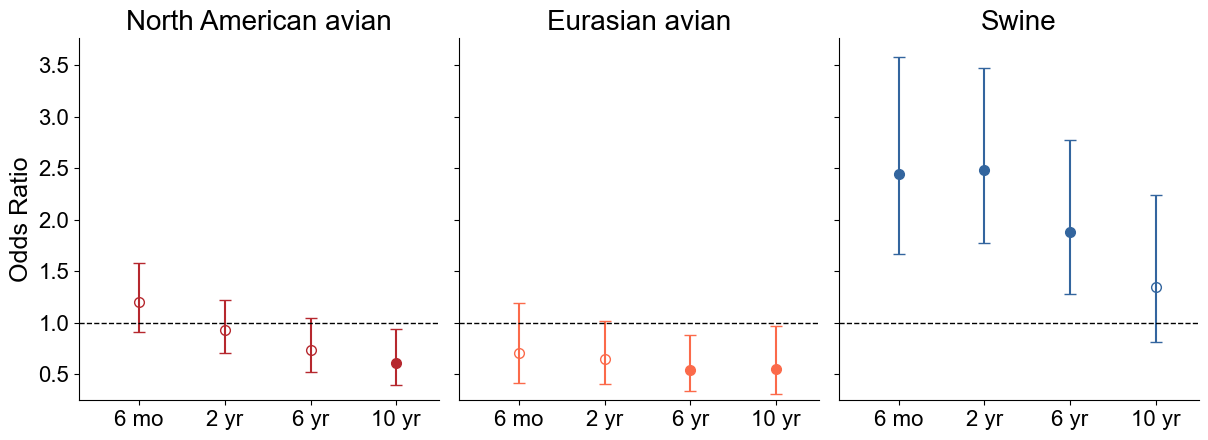

In [8]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
 
periods = ["6mo", "2yr", "6yr", "10yr"]
 
colors = {
    "na_avian": "#b6282e",
    "eurasian_avian": "#fb6a4a",
    "swine": "#33659e"
}
 
clade_names = {
    "na_avian": "North American avian",
    "eurasian_avian": "Eurasian avian",
    "swine": "Swine"
}
 
all_lows = []
all_highs = []
for clade in clades:
    for period in periods:
        _, low, high, _ = data[clade][period]
        all_lows.append(low)
        all_highs.append(high)
 
ymin = min(all_lows) * 0.95
ymax = max(all_highs) * 1.05
 
 
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True)
 
for ax, clade in zip(axes, clades):
 
    x_positions = np.arange(len(periods))
 
    for i, period in enumerate(periods):
        or_val, low, high, p = data[clade][period]
 
        # Determine marker fill based on p-value
        if p > 0.05:
            markerfacecolor = 'none'
        else:
            markerfacecolor = colors[clade]
 
        ax.errorbar(
            x_positions[i],
            or_val,
            yerr=[[or_val - low], [high - or_val]],
            fmt='o',
            capsize=4,
            markersize=7,
            color=colors[clade],
            markerfacecolor=markerfacecolor,
            markeredgecolor=colors[clade],
        )
 
    ax.axhline(1, linestyle="--", color="black", linewidth=1)
 
    ax.set_xticks(x_positions)
    ax.set_xticklabels(["6 mo", "2 yr", "6 yr", "10 yr"])
    ax.set_title(clade_names[clade], fontsize=20)
    ax.set_ylim(ymin-0.05, ymax)
    ax.set_xlim(-0.7, len(periods) - 0.5)
 
 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
 
axes[0].set_ylabel("Odds Ratio", fontsize=18)
 
plt.tight_layout()
plt.show()